In [1]:
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from IPython.display import display, Image

In [2]:
# Set up the API Key for this project.
from dotenv import load_dotenv

load_dotenv()

True

In [9]:
# Initialize the Model.
llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=os.getenv("GROK_API_KEY"))

# llm.invoke("").content

In [10]:
# initialize the state for our workflow.

class State(TypedDict):
    text: str
    classification: str
    entities: List[str]
    summary: str


In [18]:
# Define the node function for our worlflow.

def classification_node(state: State) -> State:
    ''' Classify the text into one of the categories: News, Blog, Research, or Other '''
    prompt = PromptTemplate(
        template="Classify the following text into one of the categories: News, Blog, Research, or Other.\n\nText:{text}\n\nCategory:",
        input_variables=["text"]
    )
    messages = HumanMessage(content=prompt.format(text=state["text"]))
    classification = llm.invoke([messages]).content.strip()

    return {"classification": classification}

In [19]:
# Define the Entity Extraction node Function.

def entity_extraction_node(state: State) -> State:
    '''Extract all the entities like (People, Organization, Location) from the given text'''
    prompt = PromptTemplate(
        template="Extract all the entities (Person, Organization, Location) from the following text. Provide the result as a comma-separated list.\n\nText:{text}\n\nEntities:",
        input_variables=["text"]
    )

    messages = HumanMessage(content=prompt.format(text=state["text"]))
    entities = llm.invoke([messages]).content.strip()

    return {"entities": entities}

In [20]:
def summarization_node(state: State) -> State:
    '''Summarize the text in one short sentence'''
    prompt = PromptTemplate(
        template="Summarize the following text in one short sentence.\n\nText:{text}\n\nSummary:",
        input_variables=["text"]
    )

    messages = HumanMessage(content=prompt.format(text=state["text"]))
    summarize = llm.invoke([messages]).content.strip()

    return {"summary": summarize}

In [21]:
# Build the entire workflow for the Langraph Summarization Tool.

workflow = StateGraph(State)

# Build the available nodes in the entire workflow
workflow.add_node("classification_node", classification_node)
workflow.add_node("entity_extraction_node", entity_extraction_node)
workflow.add_node("summarization_node", summarization_node)


# Connecting the Edges for all the nodes in the workflow.
workflow.add_edge(START, "classification_node")
workflow.add_edge("classification_node", "entity_extraction_node")
workflow.add_edge("entity_extraction_node", "summarization_node")
workflow.add_edge("summarization_node", END)


app = workflow.compile()

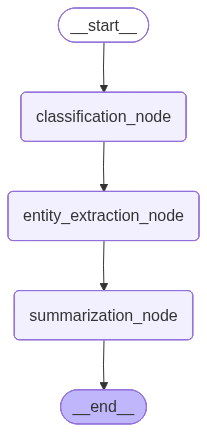

In [22]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [ ]:
# TO make sure the pipeline working fine or not we need to execute this workflow.

sample_text = """My name is Tushar Kumar and by profession """

state_input = {"text": sample_text}
result = app.invoke(state_input)

print("Classification:", result["classification"])
print("\nEntities:", result["entities"])
print("\nSummary:", result["summary"])

Classification: Category: News

Reason: The text appears to be a factual announcement about a new AI model, GPT-4, and its features, which is typical of news reporting. It lacks the personal opinion and analysis often found in blogs, and the technical detail and methodology typical of research papers. The tone is also formal and objective, suggesting a news article or press release.

Entities: OpenAI, GPT-4, GPT-3

Summary: OpenAI has announced the GPT-4 model, a large multimodal model that exhibits human-level performance and is designed to be more efficient and safer than its predecessor.
